# Jupytor Notebook

Im Rahmen der Vorlesung _Neue Konzepte: Data Science & Machine Learning_ halten wir, **Gruppe 9**, unsere Ergebnisse in diesem Jupyter Notebook fest. Unsere Mitglieder sind:
- Linus Leopold
- Taylor Baier
- Alena Ergin
- Steven Bethäuser

Wir hoffen auf eine Interessante Vorlesung und gute Zusammenarbeit.

## Formsachen

Um ein effizientes Arbeiten zu ermöglichen, wird eine klare Kommunikation angestrebt. Dazu gehören sowohl das Informieren und Aufteile ausstehender Aufgaben als auch das etablieren gemeinsamer Standards. Solche nicht dem Portfolio angehörigen Themen werden in diesem Kapitel behandelt.

In [ ]:
import numpy as np
import pandas as pd
import re
import matplotlib
import matplotlib.pyplot as plt
from PIL.features import version_codec
%matplotlib inline
#%pip install nltk
%pip install scikit-learn
import nltk
from nltk.corpus import stopwords
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import BpeTrainer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.decomposition import TruncatedSVD

from matplotlib.colors import ListedColormap
from sklearn.metrics import accuracy_score

from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV

df = pd.read_csv('Clean_Training_Essay_Data.csv')

### Ausstehende Aufgaben

In diesem Feld können anstehende To Do's getracked werden.
- [ ] Übungsblatt 2 A4 bearbeiten
- [ ] Übungsblatt 3 bearbeiten

### Umgang mit Git (Vorschlag)

Git ist die Versionierungssoftware, welche uns die Zusammenarbeit an einem einzelnen Jupyter Notebook ermöglicht. Allgemein gilt: **Commit Early, Commit Often**
- Commit-Messages
    - **Alle** Commits werden mit einer Commit-Message versehen.
    - Diese sind auf **Deutsch**.
    - Nachrichten folgen immer folgendem **Muster**: Dieses Commit _fügt Aufgabenbeschreibung 1 hinzu_.
    - Commit Nachrichten bleiben **unter 50 Zeichen** (Github Desktop warnt euch mit einem 💡 Symbol).
- Branches
    - **Größere Aufgaben** können in Branches erstellt werden
    - Beim erstellen eines Branches wird via WhatsApp **die Gruppe informiert**.

### Arbeiten in Jupytor (Vorschlag)

Jupyter ermöglicht die Kombination von Programmcode und Markdown.
- Überschriften (mit # beginnend) werden in separaten Markdown-Kästen vom dazugehörigen Text geschrieben. So kann das Einklappen-Feature zum Ausblenden von Kapiteln verwendet werden.
- Aufgabenblätter erhalten alle ein Unterkapitel, beginnend mit einer Überschrift "Übungsblatt X" der Größe ##.

### Verwendete Programme

Alle können verwenden, was sie wollen.

Folgendes Setup funktioniert für Linus gut:
- Virtual Studio Code (VSC)
- Extension: [Python](https://marketplace.visualstudio.com/items?itemName=ms-python.python)
- Extension: [Jupyter](https://marketplace.visualstudio.com/items?itemName=ms-toolsai.jupyter)

## Übungsblatt 1

### Aufgabenstellung

**1 Gruppenzusammenstellung und Themenwahl**
- [x] Finden Sie ihr Team mit 3-4 Personen (Gruppenwahl in Moodl5..

Innerhalb der Gruppe:
- [x] Suchen Sie sich einen passenden Datensatz aus der Liste oder z.B. auf https: //kaggle.com.
- [x] Welche Fragestellung/Forschungsfrage könnten Sie anhand des Datensatzes beantworten?
- [x] Dokumentieren Sie die Auswahl in Ihrer Ausarbeitung.

**2 Python**
- [x] Richten Sie sich ihr bevorzugtes Setup zur Entwicklung mit Python ein.

### Auswahl des Datensatzes und der Forschungsfrage

Bei der Auswahl der Datensätze wurden mehrere Möglichkeiten in betracht gezogen. Das arbeiten mit Datensätzen aus Social Media, Analysedaten zur mentalen Gesundheit und die Erkennung von Ki-generiertem text stellten sich als die drei Favoriten heraus.

Nach einem kurzen Blick in die dazugehörige Datenbank viel das Arbeiten mit Daten zu der mentalen Gesundheit weg. Niemand von uns will den Rest der Vorlesung damit verbringen, die Nachrichten von depressiven Menschen mit den Nachrichten von suizidalen Menschen zu vergleichen.

In unserer Gruppe kam bereits in der vorherigen Gruppenaufgabe, dem untersuchen von Nachrichten auf Falschmeldungen, das Thema KI-generierter Text auf. Deshalb viel schließlich der Entschluss, von menschen geschriebenen Text mit KI-generiertem Text zu vergleichen.
Unsere Forschungsfrage lautet also wie folgt:

**Kann KI-generierter Text anhand von klaren Eigenschaften von menschgemachtem Text unterschieden werden?**

Für diese Untersuchung bieteten sich zwei Datensätze an:
- [AI Generated Text Dataset](https://www.kaggle.com/datasets/denvermagtibay/ai-generated-essays-dataset)
- [LLM - Detect AI Generated Text Dataset](https://www.kaggle.com/datasets/sunilthite/llm-detect-ai-generated-text-dataset)

Da wir in den Datensätzen nach klaren Eigenschaften suchen, die menschliches oder KI Schreibverhalten ausmachen, empfahl Frau Prof. Dr. Schoch, nur einen der beiden Datensätze zu verwenden. Andernfalls würden Unterschiede der Datensätze die Analyse erschweren.

Der erste Datensatz enthält lediglich 1.460 Einträge, 6% davon KI generiert. Der Zweite enthält hingegen über 27.000 Einträge mit 40% dieser KI-generiert. Deshalb wird für diese Arbeit der zweite Datensatz gewählt.

## Vorlesung 2

Im Rahmen der Vorlesung 2 standen drei Vorgehensmodelle für dieses Projekt zur Auswahl:
- CRISP DM
- TDSP
- CRISP ML(Q)

Wir entscheiden uns für **CRISP DM**, da der eingeschränkte Rahmen des Projektes die limitierungen des Modelles ausgleicht. Das Modell ist für kleinere, Use-Case getriebene Projekte geeignet, und passt damit zu diesem Portfolio. Der verwendete Datensatz steht von Anfang an bereit und wird während dem Projekt nicht erweitert, was ebenfalls für CRISP DM spricht.

## Übungsblatt 2

### Aufgabenstellung

**1 Business Understanding**

Für den von Ihnen gewählten Datensatz:
- Recherchieren Sie wissenschaftliche Publikationen passend zu Ihrem Datensatz.
- Welche Methodik wird angewandt? Welche Ergebnisse werden erzielt?
- Ergänzen Sie relevante Literatur im Juypter Notebook.
    - Literaturverzeichnis & Verweise hinzufügen

**2 SMART-Ziele**

Formulieren Sie eine SMART-Zielsetzung für Ihr gewähltes Portfoliothema. Passen Sie diese im Verlauf des Projektes ggf. an.


**3 Optional: NumPy Arrays und Python-Listen**

Vergleich von NumPy Arrays und Python-Listen.
Ziel: Vergleich der Berechnungsdauer einer einfachen mathematischen Operation auf ein NumPy-Array und einen Python Liste
1. Erstellen Sie eine große Python-Liste mit ``list(range(size))``
2. Erstellen Sie ein großes NumPy-Array mit den selben Elementen mit ``np.arange(size)``
3. Quadrieren Sie jedes Element beider Datenstrukturen ``(a**2)`` und messen Sie die Zeit die dafür benötigt wird ``(start = time.time())``. Beachten Sie dass Sie für die Python-Liste eine Schleife benötigen, für das Numpy-Array können Sie Matrixoperationen verwenden.
4. Was fällt Ihnen auf?
5. Verändern Sie die Anzahl der Elemente.

**4 Optional: Indexing**

Generieren Sie ein 2D NumPy-Array mit der Form (10, 10), das Zahlen von 1 bis 100 in aufsteigender Reihenfolge enthält. Nutzen Sie dazu die Funktion ``np.arange`` und ``np.reshape``.
1. Extrahieren Sie die erste, fünfte und letzte Zeile des Arrays.
2. Wählen Sie alle Elemente der 3. und 7. Spalte aus, die in ungeraden Zeilen stehen (erinnern Sie sich, dass die Indexierung bei 0 beginnt).
3. Wählen Sie ein 3x3-Subarray aus, das linke obere Ecke Ihres ursprünglichen Arrays enthält.
4. Ändern Sie jedes Element in der 2. und 4. Zeile Ihres Arrays, indem Sie es durch seinen negativen Wert ersetzen.
5. Ersetzen Sie alle Elemente, die kleiner als 25 sind im Array durch 0.

### Relevante Literatur

Um ein gutes Business Understanding zu fördern, werden wissenschaftliche Publikationen zu dem computerbasierten Unterscheiden von KI-generiertem und menschgemachtem Text recherchiert.

| Autor*innen | Jahr | Titel | Methodik | Ergebnisse | Sonstiges |
|-|-|-|-|-|-|
| Fraser et al. | 2025 | Detecting AI-Generated Text: Factors Influencing Detectability with Current Methods | Auflistung von Einflussfaktoren | Komplexes Themengebiet mit vielen Abstufungen, die für eine praktische Anwendung berücksichtigt werden müssen | doi: 10.1613/jair.1.16665 |
| Weber‑Wulff et al.  | 2023 | Testing of detection tools for AI‑generated text | Experiment mit verschiedenen Texten (Ki- & Menschgeschrieben, KI-Übersetzungen, menschlich editiert usw) und KI-Erkennungs-Werkzeugen | Werkzeuge versagen. Beweisen ist nie möglich. | doi: 10.1007/s40979-023-00146-z |
| Chakraborty et al.  | 2023 | On the Possibilities of AI-Generated Text Detection | Statistische Auswertung von Texten | KI-Erkennung sollte theoretisch möglich sein und bleiben, da KI nicht mit der selben Vielfalt wie Menschen schreibt. Die nötigen Textproben müssen dabei (pro KI) jedoch mit sich entwickelnder KI ebenfalls zunehmen. | doi: 10.48550/arXiv.2304.04736 |
| Najjar et al. | 2025 | Detecting AI-Generated Text in Educational Content: Leveraging Machine Learning and Explainable AI for Academic Integrity | KI-Erkennungssoftware wird mit eigenem Datensatz getestet. | KI kann von darauf spezialisierten KI Modellen mit einer ~80% Präzision erkannt werden. Kurze Texte sind schwerer als lange. | doi: 10.48550/arXiv.2501.03203 |
| Russel et al. | 2025 | People who frequently use ChatGPT for writing tasks are accurate and robust detectors of AI-generated text | Menschen sollen Text als KI- oder Menschgemacht einstufen und ihre Meinung begründen. | Akkurater als bestehende KI-Modelle, selbst bei Methoden zur Umgehung des Erkennens (vermenschlichen, übersetzen, zusammenfassen). Erkennen es neben Wortverwendung auch an Klarheit, Individualität und Formalität des Textes. | doi: 10.18653/v1/2025.acl-long.267 |
| Masih et al. | 2025 | Classifying human vs. AI text with machine learning and explainable transformer models | Vergleich von traditionellen ML-, Deep-Learning- (LSTM, GRU, BiLSTM, BiGRU) und Transformer-Modellen (BERT, DistilBERT, ALBERT, RoBERTa) auf balanciertem Datensatz (20.000 Samples, GPT-3.5 & GPT-4); LIME & SHAP zur Erklärbarkeit | RoBERTa erzielt höchste Accuracy (96,1 %) und übertrifft alle Baselines. Temperature Scaling und Threshold Tuning verbessern Kalibrierung. LIME/SHAP zeigen linguistische Unterschiede zwischen KI- und Menschen-Texten | doi: 10.1038/s41598-025-27377-z |
| Kökver | 2026 | AI vs. Human Text Detection: A High-Accuracy Ensemble Approach Using Machine Learning | Vergleich von ML-Algorithmen (MLP, RF, GB, LR, SVM, DT) und Ensemble-Modell auf 487.235 Textproben; user-friendly Interface für Echtzeit-Klassifikation | Ensemble-Modell erreicht 99,90 % Accuracy und übertrifft Einzelmodelle. Generalisierbarkeit bestätigt durch sekundären Datensatz ("Almost Perfect" Kappa) | doi: 10.17798/bitlisfen.1796956 |
| Pröhl et al. | 2024 | Erkennungsverfahren für KI-generierte Texte: Überblick und Architekturentwurf | Literaturüberblick über Erkennungsverfahren (statistisch, Deep Learning, Zero-Shot, kompressionsorientiert, Kennzeichnung); tabellarischer Vergleich existierender Software-Detektoren; Entwurf eines eigenen KI-Inhalte-Detektors für deutsche Sprache | Architekturentwurf für deutschsprachigen Detektor mit Trainingsdatensatz-Konzept; Limitationen bestehender Verfahren werden aufgezeigt | doi: 10.1365/s40702-024-01051-w |
| Fiedler & Döpke | 2025 | Do humans identify AI-generated text better than machines? Evidence based on excerpts from German theses | Survey-Experiment mit 63 Dozierenden einer deutschen Hochschule (Ingenieurwesen, Wirtschaft, Sozialwiss.); Bewertung kurzer Auszüge (200–300 Wörter) aus Abschlussarbeiten als KI- oder menschengeschrieben; Regressionsanalyse | Menschen erkennen KI-Texte nur knapp besser als Zufall (57 %), bei menschengeschriebenen Texten 64 %. Kein statistisch signifikanter Unterschied zu KI-Detektoren. Texte auf Professional-Niveau am schwersten zu erkennen (< 20 %) | doi: 10.1016/j.iree.2025.100321 |

### SMART-Ziel

Ziel der Gruppe 9 ist es, bis zur Abgabe des Portfolios ein ML-Modell zu entwickeln, welches die Texte des Datensatzes mit statistischer signifikanz (p <= 0,05) in KI-generierte und von Menschen geschriebene Texte zu unterteilen.

### Python Übungen

#### NumPy Arrays und Python-Listen

Die Geschwindigkeit von Quadrierung wird auf Python Listen und Numpy Listen getestet.

In [29]:
import time

# 100 Elemente

liste1 = list(range(100))
liste2 = np.arange(100)

start = time.time()
for i in liste1:
    liste1[i] = liste1[i]**2
print("Python Liste, 100 Elemente: ")
print(round((time.time()-start)*1000, 3), " ms")
print("")

start = time.time()
liste2**2
print("Numpy Liste, 100 Elemente: ")
print(round((time.time()-start)*1000, 3), " ms")
print("")

# 10.000 Elemente

liste1 = list(range(10000))
liste2 = np.arange(10000)

start = time.time()
for i in liste1:
    liste1[i] = liste1[i]**2
print("Python Liste, 10.000 Elemente: ")
print(round((time.time()-start)*1000, 3), " ms")
print("")

start = time.time()
liste2**2
print("Numpy Liste, 10.000 Elemente: ")
print(round((time.time()-start)*1000, 3), " ms")
print("")

# 1.000.000 Elemente

liste1 = list(range(1000000))
liste2 = np.arange(1000000)

start = time.time()
for i in liste1:
    liste1[i] = liste1[i]**2
print("Python Liste, 1.000.000 Elemente: ")
print(round((time.time()-start)*1000, 3), " ms")
print("")

start = time.time()
liste2**2
print("Numpy Liste, 1.000.000 Elemente: ")
print(round((time.time()-start)*1000, 3), " ms")

Python Liste, 100 Elemente: 
0.654  ms

Numpy Liste, 100 Elemente: 
0.251  ms

Python Liste, 10.000 Elemente: 
4.248  ms

Numpy Liste, 10.000 Elemente: 
0.535  ms

Python Liste, 1.000.000 Elemente: 
213.408  ms

Numpy Liste, 1.000.000 Elemente: 
3.699  ms


Das Arbeiten mit Numpy macht den Prozess **deutlich** schneller, besonders bei langen Listen.

#### Indexing

Es wird im folgenden die Aufgabenstellung des Übungsblattes 3 Aufgabe 4 bearbeitet, die wie folgt lautet:

Generieren Sie ein 2D NumPy-Array mit der Form (10, 10), das Zahlen von 1 bis 100 in aufsteigender Reihenfolge enthält. Nutzen Sie dazu die Funktion np.arange und np.reshape.

a) Extrahieren Sie die erste, fünfte und letzte Zeile des Arrays.

b) Wählen Sie alle Elemente der 3. und 7. Spalte aus, die in ungeraden Zeilen stehen (erinnern Sie sich, dass die Indexierung bei 0 beginnt).

c) Wählen Sie ein 3x3-Subarray aus, das linke obere Ecke Ihres ursprünglichen Arrays enthält.

d) Ändern Sie jedes Element in der 2. und 4. Zeile Ihres Arrays, indem Sie es durch seinen negativen Wert ersetzen.

e) Ersetzen Sie alle Elemente, die kleiner als 25 sind im Array durch 0.

In [30]:
import numpy as np

# Array mit Zahlen von 1 bis 100 in Form einer 10x10-Matrix generieren
# 1  2  3  ... 10
# 11 12 13 ... 20
# ...
array = np.arange(1, 101).reshape(10, 10)
print("Array vor Bearbeitung: ")
print(array)

# Aufgabenteil a)
# erste, fünfte und letzte Zeile des Arrays extrahieren
a = array[[0, 4, 9], :]
# [0, 4, 9] wählt die Zeilen aus
# : meint alle Spalten auswählen
print("\nAufgabenteil a): ")
print(a)

# Aufgabenteil b)
# alle Elemente der 3. und 7. Spalte, die in ungeraden Zeilen stehen
b = array[1::2, [2, 6]]
# 1::2 meint jede zweite Zeile, beginnend bei 1
# [2, 6] meint Spalten mit Index 2 und 6
print("\nAufgabenteil b): ")
print(b)

# Aufgabenteil c)
# 3x3-Subarray, das die linke obere Ecke des ursprünglichen Arrays enthält
c = array[:3, :3]
# :3 meint alle Zeilen bis 3 (0, 1, 2)
# 3: meint alle Spalten bis 3
print("\nAufgabenteil c): ")
print(c)

# Aufgabenteil d)
# jedes Element der 2. und 4. Zeile negieren
d = -array[[1, 3], :]
# -array negiert die Zahlen
# [1, 3] wählt Zeilen aus
# : meint jede Spalte
print("\nAufgabenteil d): ")
print(d)

# Aufgabenteil e)
# alle Elemente, die kleiner als 25 sind, durch 0 ersetzen
e = array
e[e < 25 ] = 0
# e < 25 liefert für jeden Wert kleiner 25 true
# = 0 setzt die true-Werte auf 0
print("\nAufgabenteil e): ")
print(e)

Array vor Bearbeitung: 
[[  1   2   3   4   5   6   7   8   9  10]
 [ 11  12  13  14  15  16  17  18  19  20]
 [ 21  22  23  24  25  26  27  28  29  30]
 [ 31  32  33  34  35  36  37  38  39  40]
 [ 41  42  43  44  45  46  47  48  49  50]
 [ 51  52  53  54  55  56  57  58  59  60]
 [ 61  62  63  64  65  66  67  68  69  70]
 [ 71  72  73  74  75  76  77  78  79  80]
 [ 81  82  83  84  85  86  87  88  89  90]
 [ 91  92  93  94  95  96  97  98  99 100]]

Aufgabenteil a): 
[[  1   2   3   4   5   6   7   8   9  10]
 [ 41  42  43  44  45  46  47  48  49  50]
 [ 91  92  93  94  95  96  97  98  99 100]]

Aufgabenteil b): 
[[13 17]
 [33 37]
 [53 57]
 [73 77]
 [93 97]]

Aufgabenteil c): 
[[ 1  2  3]
 [11 12 13]
 [21 22 23]]

Aufgabenteil d): 
[[-11 -12 -13 -14 -15 -16 -17 -18 -19 -20]
 [-31 -32 -33 -34 -35 -36 -37 -38 -39 -40]]

Aufgabenteil e): 
[[  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0  25  26  27  28  29  30]
 [ 31  32  33  34  35

## Übungsblatt 3

### Aufgabenstellung

**1 Data Understanding I**
- [x] Lesen Sie den von Ihnen gewählten Datensatz ein.
- [x] Geben Sie die ersten 5 Zeilen aus.
- [x] Wie viele Zeilen und Spalten hat der Datensatz?
- [x] Wie heißen die Spalten? Ist intuitiv klar, welche Informationen in den Variablen enthalten ist?
- [x] Wenden Sie ``df.describe()`` an. Was fällt Ihnen auf?
- [x] Notieren Sie die Informationen.

**2 Data Understanding II**

Für den von Ihnen gewählten Datensatz:
- [x] Erstellen Sie eine Übersicht (Tabelle) über die Merkmale die im von Ihnen gewählten Datensatz enthalten sind. Welche Bedeutung und welche Skalenniveaus haben diese (vgl. Statistik- nominal, ordinal oder kardinal)? Wie viele Zeilen und Spalten gibt es (``df.info()``)?
- [x] Gibt es Merkmale die nicht relevant sind für Ihren Anwendungsfall?
- [x] Erstellen Sie Visualisierungen, z.B. der Verteilung der Zielvariablen.

**3 Data Understanding - Visualisierungen**
- [x] Erstellen Sie Visualisierungen Ihres Datensatzes. Was fällt Ihnen auf?
- [x] Können Sie neue Erkenntnisse gewinnen?

### Data Understanding I

In [31]:
# Lese den Datensatz ein
# odf, da es sich um den old data frame handelt, der später bereinigt wurde.
odf = pd.read_csv('Training_Essay_Data.csv')

In [32]:
# Zeige die ersten 5 Zeilen an
odf.head()

,text,generated
0,Car-free cities have become a subject of incre...,1
1,"Car Free Cities Car-free cities, a concept ga...",1
2,A Sustainable Urban Future Car-free cities ...,1
3,Pioneering Sustainable Urban Living In an e...,1
4,The Path to Sustainable Urban Living In an ...,1


In [33]:
# Zähle die Zeilen und Spalten
odf.count()

text         29145
generated    29145
dtype: int64

Die **zwei Spalten** werden mit Namen angezeigt.
Beide zeigen die Anzahl an Einträgen, also hat die Tabelle **29145 Zeilen**.

Die Bennung der ersten Spalte ist intuitiv. Bei der zweiten Spalte muss beachtet werden, dass sie nichts generiertes, sondern eine Zahl, die eine Aussage über die Generierung trifft, enthält.

In [34]:
# Führe df.describe() aus
odf.describe(include="all")

,text,generated
count,29145,29145.000000
unique,27340,NaN
top,For the vote for the president of the United S...,NaN
freq,3,NaN
mean,NaN,0.399279
std,NaN,0.489759
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,0.000000
75%,NaN,1.000000


Der Ursprüngliche Befehl zeigt nur Ergebnisse für die "generated" Spalte an, welche nur 1 und 0 enthält. Deshalb wurde die Untersuchung auf "all" erweitert. 

Viele der Texte sind mehrfach enthalten. Solche Dopplungen sollten vor einer weiterverarbeitung entfernt werden. Kein Text ist öfter als dreimal enthalten.

### Bereinigung

Um den Datensatz zu bereinigen wird eine Kopie erstellt, damit die bisherigen Untersuchungen erhalten bleiben.

In [35]:
# Kopie erhält Standardnamen df, um zukünftiges Bearbeiten zu erleichtern.
#df = pd.read_csv('Clean_Training_Essay_Data.csv')

Diese Kopie wird anschließend mit dem ``drop_duplicates`` Befehl bearbeitet. Dieser wird so modifiziert, das kein neuer DataFrame für die Modifikation erstellt wird. Durch das händische kopieren der Datei kann die bloße Datei später auch mit anderen Methoden untersucht oder an dritte weitergegeben werden.

In [36]:
#inplace == in dem DataFrame
df.drop_duplicates(inplace=True)

Die so erhaltene Datenbank wird erneut auf Duplikate im Text untersucht. So kann geprüft werden, ob Texte sich in unterschiedlichen Einträgen wiederholen, also ob der selbe Text einen Eintrag als KI-generiert und einen Eintrag als von Menschen geschrieben hat.

In [37]:
df.describe(include=str)

,text
count,27340
unique,27340
top,Car-free cities have become a subject of incre...
freq,1


Keiner der Texte kommt mehrfach vor. Der Datensatz ist somit bereinigt.

### Data Understanding II

In [38]:
df.info()

<class 'pandas.DataFrame'>
Index: 27340 entries, 0 to 27766
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   text       27340 non-null  str  
 1   generated  27340 non-null  int64
dtypes: int64(1), str(1)
memory usage: 57.6 MB


Der Datensatz enthält lediglich zwei Spalten. In folgender Tabelle werden ihre Bedeutung, ihr Datentyp und ihr statistisches Skalenniveau dargestellt.

In [39]:
merkmale = pd.DataFrame({
    "Merkmal": ["text", "generated"],
    "Bedeutung": [
        "Essay-Text – Eingabevariable, auf deren Basis klassifiziert werden soll.",
        "Label: 0 = von Menschen geschrieben, 1 = KI-generiert. Zielvariable der Klassifikation."
    ],
    "Datentyp": [str(df["text"].dtype), str(df["generated"].dtype)],
    "Skalenniveau": ["nominal (Freitext, qualitativ)", "nominal (binär, dichotom)"],
    "Anzahl Einträge": [df["text"].count(), df["generated"].count()],
    "Eindeutige Werte": [df["text"].nunique(), df["generated"].nunique()],
    "Relevant?": ["ja – Eingabevariable", "ja – Zielvariable"],
})
merkmale

,Merkmal,Bedeutung,Datentyp,Skalenniveau,Anzahl Einträge,Eindeutige Werte,Relevant?
0,text,"Essay-Text – Eingabevariable, auf deren Basis ...",str,"nominal (Freitext, qualitativ)",27340,27340,ja – Eingabevariable
1,generated,"Label: 0 = von Menschen geschrieben, 1 = KI-ge...",int64,"nominal (binär, dichotom)",27340,2,ja – Zielvariable


Beide enthaltenen Merkmale sind für unseren Anwendungsfall relevant: `text` dient als Eingabe-Merkmal, `generated` als Zielvariable. Da der Datensatz keine Metadaten wie Autor, Quelle oder Zeitstempel enthält, gibt es keine irrelevanten Spalten, die entfernt werden müssten. Beide Merkmale sind **nominal skaliert**; `generated` ist zusätzlich **dichotom** (binär). Damit eignet sich der Datensatz für ein binäres Klassifikationsproblem.

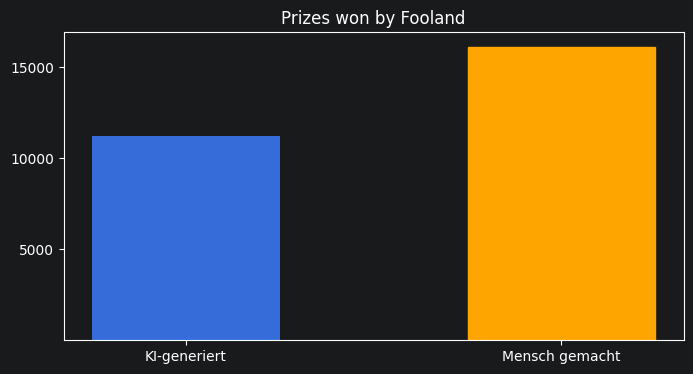

In [40]:
labels = ["KI-generiert", "Mensch gemacht"]
data = [df["generated"].value_counts()[1], df["generated"].value_counts()[0]]

bar_width = 0.5
# Manuelle Definition der Balken und Label Platzierung
# Pandas kommt mit build-in Matplotlib Plots, diese sind nutzerfreundlicher
xlocations = np.array(range(len(data))) + bar_width # Platzierung der Balken und Definition des Abstands
barlist = plt.bar(xlocations, data, width=bar_width)
barlist[1].set_color('orange')
plt.yticks([5000, 10000, 15000]) # Bereich der y-Achse
plt.xticks(xlocations, labels) # Platziert die Beschriftung der Balken
plt.title("Prizes won by Fooland")
plt.gca().get_xaxis().tick_bottom() # gca: get current axes
plt.gca().get_yaxis().tick_left()
plt.gcf().set_size_inches((8,4)) # Größe der Grafik

### Data Understanding - Visualisierungen

([<matplotlib.patches.Wedge at 0x101fb52c7d0>,
 [Text(0.30584611049759997, 1.0566258357117198, 'KI-generiert'),
  Text(-0.30584601812443085, -1.056625862449633, 'Mensch gemacht')],
 [Text(0.16682515118050906, 0.5763413649336652, '41.0%'),
  Text(-0.16682510079514407, -0.5763413795179815, '59.0%')])

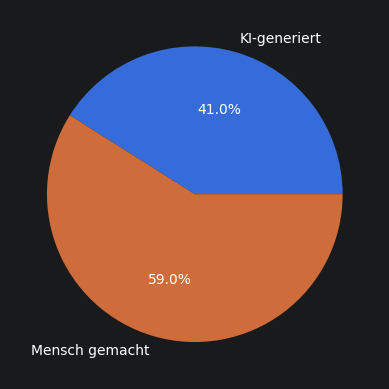

In [41]:
labels = ["KI-generiert", "Mensch gemacht"]
sizes = [df["generated"].value_counts()[1], df["generated"].value_counts()[0]]

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%')

Aufgrund der geringen Merkmalsanzahl ist die Menge der möglichen Auswertungen recht gering. Das verhältnis der vorhandenen Datenmengen für generierte und geschriebene Texte ist für das Trainieren einer ML jedoch sehr relevant. Da dieser Faktor bereits bei der Datensatzwahl berücksichtigt wurde, ist das Ergebnis hier nichtmehr überraschend.

## Übungsblatt 4

### Aufgabenstellung

**1 Datenqualität**

Für den von Ihnen gewählten Datensatz:
- [x] Analysieren Sie ob der Datensatz fehlende Werte enthält. Falls ja, entscheiden Sie wie Sie damit umgehen (löschen oder ersetzen) und Begründen Sie Ihre Entscheidung.
- [x] Analysieren Sie ob der Datensatz Duplikate enthält. Falls ja, wie gehen Sie damit um?
- [ ] Analysieren Sie ob der Datensatz andere fehlerhafte Werte enthält (vgl. Vorlesung). Falls ja, finden Sie geeignete Lösungsstrategien und wenden Sie diese falls möglich an.
- [ ] Gibt es in Ihrem Datensatz weitere Qualitätsprobleme?

**2 Optional: Matplotlib- Erstellen eines Linienplots**
Erstellen Sie eine Grafik der Durchschnittstemperaturen (in °C) für zwei Städte über ein Jahr mit Hilfe von matplotlib.
- [ ] Verwenden Sie die Durchschnittstemperaturen für Karlsruhe und Berlin

```
monate = [’Jan’, ’Feb’, ’Mär’, ’Apr’, ’Mai’, ’Jun’, ’Jul’, ’Aug’, ’Sep’, ’Okt’, ’Nov’, ’Dez’]
T_ka = [0, 1, 5, 9, 14, 18, 20, 19, 14, 9, 4, 1]
T_berlin = [-2, 0, 4, 8, 13, 17, 19, 18, 13, 8, 3, 0]
```

- [ ] Linienplot: Erstellen Sie für jede Stadt einen Linienplot, der die monatlichen Durchschnittstemperaturen zeigt. Verwenden Sie unterschiedliche Farben oder Linienstile für jede Stadt. Importieren Sie import matplotlib.pyplot as plt und erstellen Sie den Plot mit ``plt.plot()``.
- [ ] Achsenbeschriftungen: Die x-Achse soll die Monate und die y-Achse die Temperatur in °C anzeigen. Verwenden Sie ``plt.xlabel()`` und ``plt.ylabel()``.
- [ ] Legende: Fügen Sie eine Legende hinzu, um zu kennzeichnen, welche Linie zu welcher Stadt gehört mit ``plt.legend()``.
- [ ] Titel: Geben Sie Ihrem Plot einen Titel mit ``plt.title()``.
- [ ] Aktivieren Sie das Gitter mit ``plt.grid(True)``

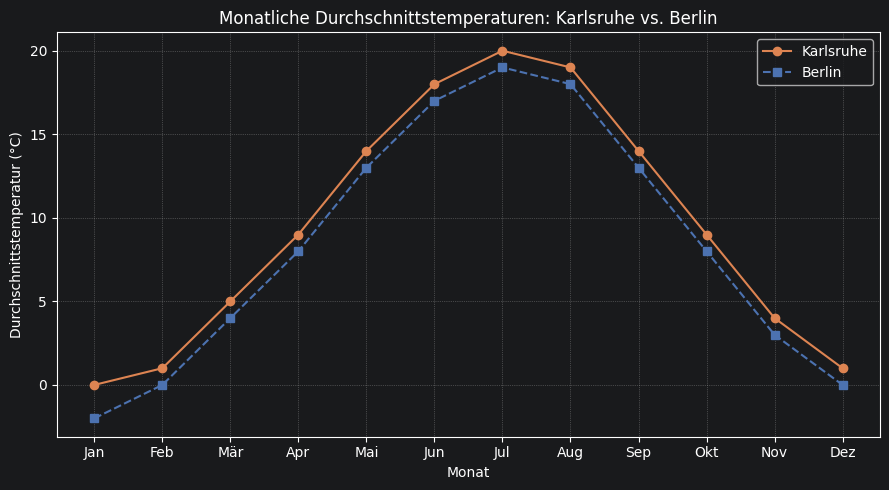

In [42]:
import matplotlib.pyplot as plt  
monate = ['Jan', 'Feb', 'Mär', 'Apr', 'Mai', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez']
T_ka     = [0, 1, 5, 9, 14, 18, 20, 19, 14, 9, 4, 1]
T_berlin = [-2, 0, 4, 8, 13, 17, 19, 18, 13, 8, 3, 0]

# (b) Linienplot für beide Städte mit unterschiedlichen Farben und Linienstilen
plt.figure(figsize=(9, 5))
plt.plot(monate, T_ka,     color="#DD8452", linestyle="-",  marker="o", label="Karlsruhe")
plt.plot(monate, T_berlin, color="#4C72B0", linestyle="--", marker="s", label="Berlin")

# (c) Achsenbeschriftungen
plt.xlabel("Monat")
plt.ylabel("Durchschnittstemperatur (°C)")
plt.title("Monatliche Durchschnittstemperaturen: Karlsruhe vs. Berlin")

# (d) Legende
plt.legend()

plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

### Datenqualität

#### Fehlende Werte

Da Zeilen, bei welchen der Text oder die Zuordnung fehlen keinen Nutzen haben, dürfen sie so nicht im Dtensatz bleiben. Einen eigenen Text hinzufügen geht nicht, und mögliche Fehleinschätzungen machen das bewerten eines vorhandenen Textes ohne Zuordnung riskant. Deshalb werden alle Zeilen mit fehlenden werden gelöscht. Vor der Veränderung hatt der Datensatz 29145 Zeilen. Nach dem Vorgang hat sich daran nichts verändert.

In [43]:
df.dropna()
df.count()

text         27340
generated    27340
dtype: int64

#### Duplikate

Duplikate wurden bereits in einem früheren Schritt entdeckt und eigenständig entfernt. Ihr erhalt hat für diesen Datensatz keinen mehrwert.

#### Fehlerhafte Werte

Der Datensatz wird auf fehlerhafte Werte mithilfe der folgenden Suchkriterien untersucht.
- Texte mit unbekannten Symbolen (Nicht Alpha-Numerisch oder Satzzeichen).
- Texte mit Zahlen.
- Generated-Zahl, die weder 1 noch 0 ist.
- Texte mit doppelten Leerzeichen.
- Texte die leere Strings sind.

In [44]:
#Texte mit unbekannten Symbolen (Nicht Alpha-Numerisch oder Satzzeichen).
erwartete_zeichen = r'[^\w\s\.\,\-\'\:\(\)\[\]\{\}\!\?\&\=\#\|\/\$\£\"\%\;\+\*\@\<\>\\\°\~\®\™\¬\©\♡\☺\😜\😊\😁\😊\•\¡\…\´\`\’\‘\“\”\¸\—\–\─\―\‒\¸\¨\·\^\x9b\xad\x92\x97\x83\x91\x93\x94\x82\x80\x99\xb6\u200b\ufe0f\u0301]'

sonderzeichen_df = df[df['text'].str.contains(erwartete_zeichen, regex=True)]
sonderzeichen_df['sonderzeichen'] = sonderzeichen_df['text'].str.findall(erwartete_zeichen)

sonderzeichen_df['unicode_codes'] = sonderzeichen_df['sonderzeichen'].apply(
    lambda zeichen_liste: [c.encode('unicode-escape').decode('utf-8') for c in zeichen_liste]
)

with pd.option_context('display.max_colwidth', None):
    print(sonderzeichen_df)

ArrowInvalid: Invalid regular expression: invalid escape sequence: \£

- ``¸`` wird in Datensatz 3378 statt einem Komma verwendet.
- ``¨`` ist in mehreren Datensätzen zu finden und erfüllt dort keine Rolle. Es scheint sich um eine Art Artefakt zu handeln.
- ``·`` wird als Teil einer Quellenangabe verwendet.
- ``¢`` taucht an einigen Stellen in korrupierten Textabschnitten auf.

Einige andere Zeichen werden in der Ausgabe nicht angezeigt, weshalb zusätzlich die Unicode Kürzel betrachtet werden.
- ``\x9b``, ``\x80``, ``\x82``, ``\x99``, ``\x91``, ``\x83`` sind Steuerzeichen für die Formatierung von Dokumenten.
- ``\xad`` zeigt in langen Worten an, wo es von einem Textprogramm getrennt werden darf. Es wird selbst nicht angezeigt.
- ``\x92`` ist ein Codierungsartefakt der Textumwandlung aus der Windows-Codierung hin zu UTF-8.
- ``\x97`` Steht in alten Windows-Systemen für Em-Dashes, ist in neueren Systemen jedoch lediglich ein Formatierungszeichen.
- ``\xb6`` Signalisiert das Ende einer Zeile in Schreibsoftware wie Word.
- ``\u200b`` idt ein Leerzeichen ohne breite, welches für Wortumbrüche verwendet werden kann.
- ``\ufe0f`` und ``\u0301`` sind Kreise mit gepunkteten Linien (und im zweiten mit einem Aktzent).
- ``\x93`` und ``\x94`` markieren in Systemen wie Word das " als öffnend und schließend.

In [ ]:
#Generated-Zahl, die weder 1 noch 0 ist.
fehlbewertet_df = df[~df['generated'].isin([0, 1])]
print(fehlbewertet_df)

Nun werden die ungewollten oder außergewöhnlichen SOnderzeichen gesucht und die Umgebung auf Fehler oder kaputte Daten untersucht.

In [ ]:
zeichen = '¨' # gesuchtes Zeichen
anzahl = 50 # Wieviele Symbole nach rechts/links

escaped_zeichen = re.escape(zeichen) # Zeichen für Regex umformatieren

regex_muster = f"(.{{0,{anzahl}}})({escaped_zeichen})(.{{0,{anzahl}}})"

ergebnisse = df['text'].str.extractall(regex_muster)

ergebnisse.columns = ['vorher', 'zeichen', 'nachher']
ergebnisse['textabschnitt'] = ergebnisse['vorher'] + ergebnisse['zeichen'] + ergebnisse['nachher']

with pd.option_context('display.max_colwidth', None): # Zeige ganzen Text an
    print(ergebnisse[['textabschnitt']])

Das Symbol ¢ kam viermal im Text vor.
~~~
...know what to do, so if you had a problem like "3Ã¢â¬Â¢5+2" you know what to do, you multiply 3 and...
...how to do it, if you know how to do it you know 3Ã¢â¬Â¢5 is 15 and 15+2 is 17. Having a better under...
...ns can help someone make a better choice. theyÃâ¢e good choices a person could give you a good choi...
...TheyÃâ¢e also bad choices in some opinions. A person can...
~~~
Die ersten zwei Fälle sind Gleichungen, bei welchen das Multiplikationssymbol durch ```Ã¢â¬Â¢``` ersetzt wurde. Es wird durch das Symbol · ersetzt.

``TheyÃâ¢e`` scheint ein Fehler bei der Textkonvertierung zu sein, wobei das Original They're war. Dies wird entsprechend angepasst.

## Vorlesung 5

### Aufgabe 1

- Wenden Sie die oben vorgestellte Tokenisierung auf Ihren Datensatz an.
- Berechnen Sie die Anzahl der Word Types und Word Instances.
- Visualisieren Sie die Wortfrequenzen in einem Barchart.
- Ist das hilfreich zur Lösung Ihres Klassifikationsproblems?

In [ ]:
df["worte"]=df["text"].str.split()

word_list = np.concatenate(df["worte"].values)
print("Anzahl Worte: ", len(word_list))

word_counts = pd.Series(word_list).value_counts()
word_counts = word_counts.reset_index()
word_counts.columns = ["word", "count"]

word_counts["percent"] = (
    (word_counts["count"] / len(word_list)) * 100
)

print(word_counts.head())
print("|V|=", len(word_counts.word))

print(word_counts.head())

# Nochmal für nur KI-generierte
print()
print("KI-Generiertes:")

df_filtered_1 = df.loc[df["generated"] == 1].copy()

df_filtered_1["worte"]=df_filtered_1["text"].str.split()

word_list_1 = np.concatenate(df_filtered_1["worte"].values)
print("Anzahl Worte: ", len(word_list_1))

word_counts_1 = pd.Series(word_list_1).value_counts()
word_counts_1 = word_counts_1.reset_index()
word_counts_1.columns = ["word", "count"]


word_counts_1["percent"] = (
    word_counts_1["count"] / len(word_list_1) * 100
)

print("|V|=", len(word_counts_1.word))

print(word_counts_1.head())

# Nochmal für nur Menschgemachte
print()
print("Menschliches:")

df_filtered_2 = df.loc[df["generated"] == 0].copy()

df_filtered_2["worte"]=df_filtered_2["text"].str.split()

word_list_2 = np.concatenate(df_filtered_2["worte"].values)
print("Anzahl Worte: ", len(word_list_2))

word_counts_2 = pd.Series(word_list_2).value_counts()
word_counts_2 = word_counts_2.reset_index()
word_counts_2.columns = ["word", "count"]

word_counts_2["percent"] = (
    word_counts_2["count"] / len(word_list_2) * 100
)

print("|V|=", len(word_counts_2.word))

print(word_counts_2.head())

In [ ]:
# Top 15 Wörter
top_n = 15
top_words = word_counts.head(top_n)

# Diagramm erstellen
plt.figure(figsize=(10, 6))
plt.barh(
    top_words["word"][::-1],
    top_words["count"][::-1],
    color="skyblue",
    edgecolor="black",
)

# Beschriftungen und Design
plt.title(f"Top {top_n} der häufigsten Wörter", fontsize=14, fontweight="bold")
plt.xlabel("Häufigkeit", fontsize=12)
plt.ylabel("Wort", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)  # Hilfslinien im Hintergrund

# Diagramm anzeigen
plt.tight_layout()
plt.show()


# Nur KI-generierte Texte
top_words_1 = word_counts_1.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(
    top_words_1["word"][::-1],
    top_words_1["count"][::-1],
    color="lightgreen",
    edgecolor="black",
)

plt.title(
    f"Top {top_n} der häufigsten Wörter (KI-generiert)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Häufigkeit")
plt.ylabel("Wort")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Nur menschliche Texte
top_words_2 = word_counts_2.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(
    top_words_2["word"][::-1],
    top_words_2["count"][::-1],
    color="orange",
    edgecolor="black",
)

plt.title(
    f"Top {top_n} der häufigsten Wörter (Menschlich)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Häufigkeit")
plt.ylabel("Wort")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
english_stopwords = set(stopwords.words("english"))

# Filter
cleaned_word_list = [
    word.lower()
    for word in word_list
    if word.lower() not in english_stopwords and word.isalpha()
]

# Neue Wortanzahlen
word_counts_clean = pd.Series(cleaned_word_list).value_counts().reset_index()
word_counts_clean.columns = ["word", "count"]
total_words_clean = len(cleaned_word_list)

word_counts_clean["percent"] = (
    word_counts_clean["count"] / total_words_clean * 100
).round(2)

print(word_counts_clean.head())

# KI-generiert
print()
print("KI-generiert")
cleaned_word_list_1 = [
    word.lower()
    for word in word_list_1
    if word.lower() not in english_stopwords and word.isalpha()
]

word_counts_clean_1 = (
    pd.Series(cleaned_word_list_1)
    .value_counts()
    .reset_index()
)
word_counts_clean_1.columns = ["word", "count"]
total_words_clean_1 = len(cleaned_word_list_1)

word_counts_clean_1["percent"] = (
    word_counts_clean_1["count"] / total_words_clean_1 * 100
).round(2)

print(word_counts_clean_1.head())

# Mensch
print()
print("Menschgeschrieben")

cleaned_word_list_2 = [
    word.lower()
    for word in word_list_2
    if word.lower() not in english_stopwords and word.isalpha()
]

word_counts_clean_2 = (
    pd.Series(cleaned_word_list_2)
    .value_counts()
    .reset_index()
)
word_counts_clean_2.columns = ["word", "count"]

total_words_clean_2 = len(cleaned_word_list_2)

word_counts_clean_2["percent"] = (
    word_counts_clean_2["count"] / total_words_clean_2 * 100
).round(2)

print(word_counts_clean_2.head())

In [ ]:
#Top 15 ohne Füllwörter
# Barrendiagramm
top_n = 15
top_words = word_counts_clean.head(top_n)

plt.figure(figsize=(10, 6))
# Horizontal
plt.barh(
    top_words["word"][::-1],
    top_words["count"][::-1],
    color="salmon",
    edgecolor="black",
)

plt.title(
    f"Top {top_n} der häufigsten Worte (Ohne Füllwörter)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Häufigkeit", fontsize=12)
plt.ylabel("Wort", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

# KI-generiert


top_words_clean_1 = word_counts_clean_1.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(
    top_words_clean_1["word"][::-1],
    top_words_clean_1["count"][::-1],
    color="lightgreen",
    edgecolor="black",
)

plt.title(
    f"Top {top_n} Wörter ohne Füllwörter (KI-generiert)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Häufigkeit")
plt.ylabel("Wort")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Menschlich
top_words_clean_2 = word_counts_clean_2.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(
    top_words_clean_2["word"][::-1],
    top_words_clean_2["count"][::-1],
    color="orange",
    edgecolor="black",
)

plt.title(
    f"Top {top_n} Wörter ohne Füllwörter (Menschlich)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Häufigkeit")
plt.ylabel("Wort")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


Die KI verwendet die häufigsten nicht-Füllwörter deutlich häufiger als Menschen.
Kann dies auf Nicht-Füllwörter allgemein erweitert werden?

In [ ]:
# ---------------------------------------------------------
# Vorbereitung & Berechnung (analog zu vorher)
# ---------------------------------------------------------
stop_words = set(stopwords.words('english'))

def get_stopword_percentage(text):
    if not isinstance(text, str):
        return 0.0
    words = re.findall(r'\b\w+\b', text.lower())
    if not words:
        return 0.0
    stopwords_count = sum(1 for word in words if word in stop_words)
    return (stopwords_count / len(words)) * 100

# Spalte mit exaktem Prozentwert berechnen
df['stopword_pct'] = df['text'].apply(get_stopword_percentage)

# Auf ganze Prozentpunkte runden für die Einzelpunkt-Analyse
df['stopword_pct_rounded'] = df['stopword_pct'].round(0).astype(int)

# Gesamtanzahl pro Gruppe ermitteln
total_gen_0 = (df['generated'] == 0).sum()
total_gen_1 = (df['generated'] == 1).sum()

# ---------------------------------------------------------
# Daten für den Linienplot vorbereiten
# ---------------------------------------------------------
# Alle möglichen Prozentpunkte von 0 bis 100 abdecken
all_pct_points = pd.Series(0, index=range(0, 101))

# Absolute Häufigkeiten zählen
counts_0 = df[df['generated'] == 0]['stopword_pct_rounded'].value_counts()
counts_1 = df[df['generated'] == 1]['stopword_pct_rounded'].value_counts()

# Fehlende Prozentpunkte mit 0 auffüllen und relative Häufigkeit berechnen
# (Anteil an der jeweiligen Gesamtgruppe)
pct_data_0 = all_pct_points.add(counts_0, fill_value=0) / total_gen_0
pct_data_1 = all_pct_points.add(counts_1, fill_value=0) / total_gen_1

# ---------------------------------------------------------
# Linienplot erstellen
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# Linien zeichnen
ax.plot(pct_data_0.index, pct_data_0.values, label='Generated 0 (Mensch)', color='blue', linewidth=2)
ax.plot(pct_data_1.index, pct_data_1.values, label='Generated 1 (KI)', color='orange', linewidth=2)

# Achsenbeschriftungen und Formatierung (Y-Achse in Prozent)
ax.set_title('Verteilung des Stopword-Anteils (Relative Häufigkeit pro Gruppe)', fontsize=14)
ax.set_xlabel('Stopword-Anteil (in %)', fontsize=12)
ax.set_ylabel('Anteil an allen Texten der Gruppe', fontsize=12)

# Y-Achsen-Formatierung auf Prozent (0.05 wird zu 5%)
vals = ax.get_yticks()
ax.set_yticklabels(['{:,.1%}'.format(x) for x in vals])

# X-Achse in 5er- oder 10er-Schritten für bessere Lesbarkeit
plt.xticks(range(0, 101, 5))

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Gruppen', fontsize=11)
plt.tight_layout()

# Diagramm anzeigen
plt.show()


### Klassifikator bauen

If/Else annahme als Spalte machen & vergleichen
- Sonderzeichen
- Füllwörter

### Aufgabe 2: Byte-Pair-Encoding

- Wenden Sie Byte-Pair-Encodign auf Ihren Datensatz an.
- Verändern Sie die vocab_size - welchen Einfluss hat sie auf die Token?
- Erstellen Sie die Visualisierungen der am häufigsten vorkommenden Token.

In [ ]:
tokenizer = Tokenizer(BPE())
tokenizer.pre_tokenizer = Whitespace()
trainer = BpeTrainer(vocab_size=50000)

tokenizer.train_from_iterator(df.text, trainer)

all_tokens = []
for sentence in df.text:
    encoded = tokenizer.encode(sentence)
    all_tokens.extend(encoded.tokens)

# Häufigkeiten
token_series = pd.Series(all_tokens)
token_freq = token_series.value_counts()
top_n = 15
top_tokens = token_freq.head(top_n)

# Barplot
plt.figure(figsize=(10,6))
plt.bar(top_tokens.index, top_tokens.values)
plt.title(f"Top {top_n} häufigste BPE-Token bei vocab_size=50.000")
plt.xlabel("Token")
plt.ylabel("Häufigkeit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
tokenizer = Tokenizer(BPE())
tokenizer.pre_tokenizer = Whitespace()
trainer = BpeTrainer(vocab_size=25000)

tokenizer.train_from_iterator(df.text, trainer)

all_tokens = []
for sentence in df.text:
    encoded = tokenizer.encode(sentence)
    all_tokens.extend(encoded.tokens)

# Häufigkeiten
token_series = pd.Series(all_tokens)
token_freq = token_series.value_counts()
top_n = 15
top_tokens = token_freq.head(top_n)

# Barplot
plt.figure(figsize=(10,6))
plt.bar(top_tokens.index, top_tokens.values)
plt.title(f"Top {top_n} häufigste BPE-Token bei vocab_size=25.000")
plt.xlabel("Token")
plt.ylabel("Häufigkeit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
tokenizer = Tokenizer(BPE())
tokenizer.pre_tokenizer = Whitespace()
trainer = BpeTrainer(vocab_size=5000)

tokenizer.train_from_iterator(df.text, trainer)

all_tokens = []
for sentence in df.text:
    encoded = tokenizer.encode(sentence)
    all_tokens.extend(encoded.tokens)

# Häufigkeiten
token_series = pd.Series(all_tokens)
token_freq = token_series.value_counts()
top_n = 15
top_tokens = token_freq.head(top_n)

# Barplot
plt.figure(figsize=(10,6))
plt.bar(top_tokens.index, top_tokens.values)
plt.title(f"Top {top_n} häufigste BPE-Token bei vocab_size=5.000")
plt.xlabel("Token")
plt.ylabel("Häufigkeit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
tokenizer = Tokenizer(BPE())
tokenizer.pre_tokenizer = Whitespace()
trainer = BpeTrainer(vocab_size=500)

tokenizer.train_from_iterator(df.text, trainer)

all_tokens = []
for sentence in df.text:
    encoded = tokenizer.encode(sentence)
    all_tokens.extend(encoded.tokens)

# Häufigkeiten
token_series = pd.Series(all_tokens)
token_freq = token_series.value_counts()
top_n = 15
top_tokens = token_freq.head(top_n)

# Barplot
plt.figure(figsize=(10,6))
plt.bar(top_tokens.index, top_tokens.values)
plt.title(f"Top {top_n} häufigste BPE-Token bei vocab_size=500")
plt.xlabel("Token")
plt.ylabel("Häufigkeit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
tokenizer = Tokenizer(BPE())
tokenizer.pre_tokenizer = Whitespace()
trainer = BpeTrainer(vocab_size=50)

tokenizer.train_from_iterator(df.text, trainer)

all_tokens = []
for sentence in df.text:
    encoded = tokenizer.encode(sentence)
    all_tokens.extend(encoded.tokens)

# Häufigkeiten
token_series = pd.Series(all_tokens)
token_freq = token_series.value_counts()
top_n = 15
top_tokens = token_freq.head(top_n)

# Barplot
plt.figure(figsize=(10,6))
plt.bar(top_tokens.index, top_tokens.values)
plt.title(f"Top {top_n} häufigste BPE-Token bei vocab_size=50")
plt.xlabel("Token")
plt.ylabel("Häufigkeit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
tokenizer = Tokenizer(BPE())
tokenizer.pre_tokenizer = Whitespace()
trainer = BpeTrainer(vocab_size=5)

tokenizer.train_from_iterator(df.text, trainer)

all_tokens = []
for sentence in df.text:
    encoded = tokenizer.encode(sentence)
    all_tokens.extend(encoded.tokens)

# Häufigkeiten
token_series = pd.Series(all_tokens)
token_freq = token_series.value_counts()
top_n = 15
top_tokens = token_freq.head(top_n)

# Barplot
plt.figure(figsize=(10,6))
plt.bar(top_tokens.index, top_tokens.values)
plt.title(f"Top {top_n} häufigste BPE-Token bei vocab_size=5")
plt.xlabel("Token")
plt.ylabel("Häufigkeit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Vektorisierung

## Bag-of-Words Vektorisierung

In [ ]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df['text'])

print(X)

print(vectorizer.get_feature_names_out())
X.toarray()

max_tf_idf = np.max(X.toarray(), axis=0)

# 2. DataFrame mit Tokens und ihren Gewichtungen erstellen
feature_scores = pd.DataFrame({
    'Token': vectorizer.get_feature_names_out(),
    'Häufigkeit': max_tf_idf
})

# 3. Nach Gewichtung absteigend sortieren und die Top 40 holen
feature_scores.sort_values(by='Häufigkeit', ascending=False).head(40)

## TF-IDF Vektorisierung

In [ ]:
vectorizer = TfidfVectorizer()

Y = vectorizer.fit_transform(df['text'])

print(Y)

print(vectorizer.get_feature_names_out())
Y.toarray()

max_tf_idf = np.max(Y.toarray(), axis=0)

# 2. DataFrame mit Tokens und ihren Gewichtungen erstellen
feature_scores = pd.DataFrame({
    'Token': vectorizer.get_feature_names_out(),
    'Gewichtung': max_tf_idf
})

# 3. Nach Gewichtung absteigend sortieren und die Top 40 holen
feature_scores.sort_values(by='Gewichtung', ascending=False).head(40)

## N-grams Vektorisierung

In [ ]:
vectorizer = TfidfVectorizer(
    ngram_range=(2,2)
)

Z = vectorizer.fit_transform(df['text'])

print(Z)

feature_names = vectorizer.get_feature_names_out()

print(feature_names)

# Durchschnittlichen TF-IDF-Wert pro Feature berechnen
mean_tfidf = np.asarray(Z.mean(axis=0)).flatten()

# Top 20 Features
top_indices = mean_tfidf.argsort()[-20:][::-1]

top_features = feature_names[top_indices]
top_scores = mean_tfidf[top_indices]

plt.figure(figsize=(10,6))
plt.barh(top_features[::-1], top_scores[::-1])
plt.xlabel("Durchschnittlicher TF-IDF-Wert")
plt.title("Wichtigste Tokens / N-Grams mit stopwords")
plt.show()

In [ ]:
vectorizer = TfidfVectorizer(
    ngram_range=(2,2),
    stop_words='english'
)

Z = vectorizer.fit_transform(df['text'])

print(Z)

feature_names = vectorizer.get_feature_names_out()

print(feature_names)

# Durchschnittlichen TF-IDF-Wert pro Feature berechnen
mean_tfidf = np.asarray(Z.mean(axis=0)).flatten()

# Top 20 Features
top_indices = mean_tfidf.argsort()[-20:][::-1]

top_features = feature_names[top_indices]
top_scores = mean_tfidf[top_indices]

plt.figure(figsize=(10,6))
plt.barh(top_features[::-1], top_scores[::-1])
plt.xlabel("Durchschnittlicher TF-IDF-Wert")
plt.title("Wichtigste Tokens / N-Grams ohne stopwords")
plt.show()

# KNN Modell

Validierungsgenauigkeit: 0.5340805123513266
Testgenauigkeit: 0.5388838060384263


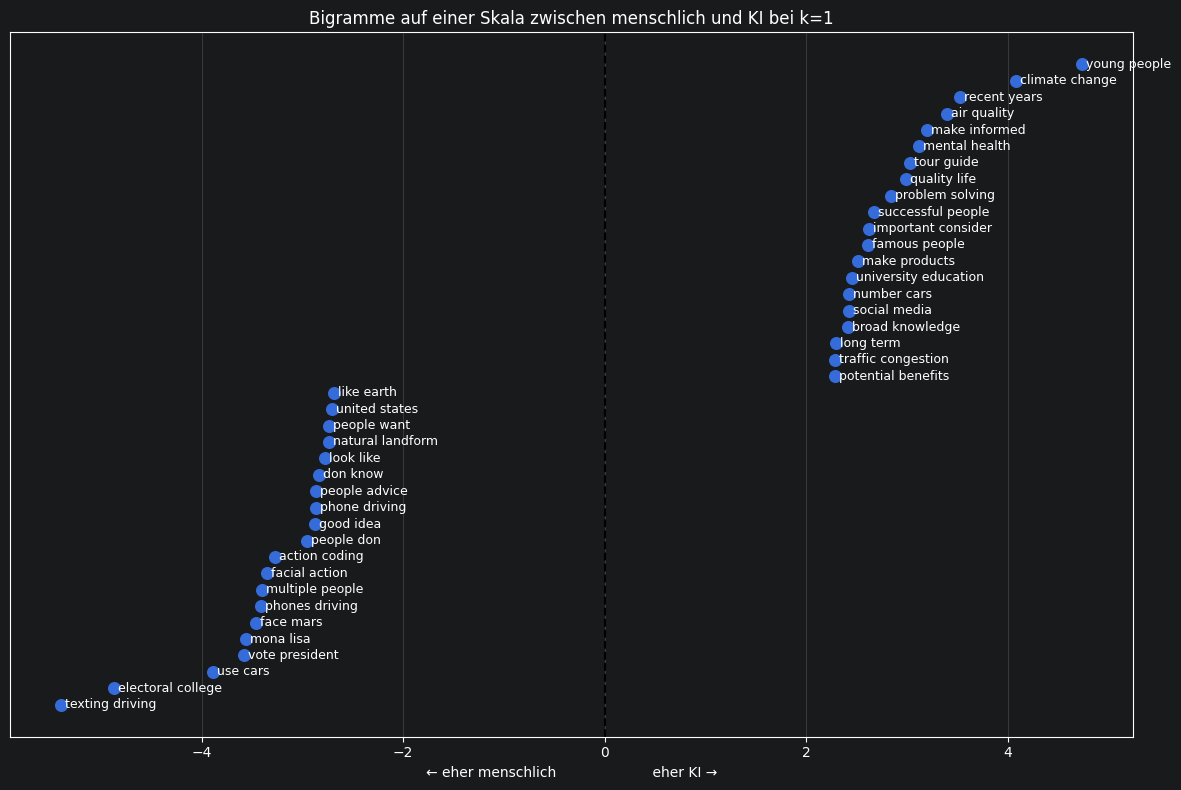

In [66]:
# Texte und Labels
X = df["text"]
Y = df["generated"]

# Erst Training (70 %) und Rest (30 %) erzeugen
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=42,
    stratify=Y
)

# Rest halbieren -> 15 % Validierung, 15 % Test
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=42,
    stratify=Y_temp
)

# TF-IDF-Vektorisierung
vectorizer = TfidfVectorizer(
    ngram_range=(2,2),
    stop_words="english"
)

X_train = vectorizer.fit_transform(X_train)
X_val = vectorizer.transform(X_val)
X_test = vectorizer.transform(X_test)


# k-NN trainieren (für die eigentliche Klassifikation)
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, Y_train)

Y_val_pred = knn.predict(X_val)

print("Validierungsgenauigkeit:",
      accuracy_score(Y_val, Y_val_pred))

Y_test_pred = knn.predict(X_test)

print("Testgenauigkeit:",
      accuracy_score(Y_test, Y_test_pred))

# ---------------------------------------------------------
# Nur für die Visualisierung:
# Logistische Regression liefert Gewichte für jedes Bigramm
# ---------------------------------------------------------

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, Y_train)

# Bigramme und ihre Gewichte
bigrams = vectorizer.get_feature_names_out()
weights = lr.coef_[0]

importance = pd.DataFrame({
    "Bigram": bigrams,
    "Gewicht": weights
})

importance = importance.sort_values("Gewicht")

# Die 20 menschlichsten und 20 KI-typischsten Bigramme
top = pd.concat([
    importance.head(20),
    importance.tail(20)
])

# Visualisierung
plt.figure(figsize=(12, 8))

plt.scatter(
    top["Gewicht"],
    range(len(top)),
    s=70
)

for i, (_, row) in enumerate(top.iterrows()):
    plt.text(
        row["Gewicht"],
        i,
        " " + row["Bigram"],
        va="center",
        fontsize=9
    )

plt.axvline(0, color="black", linestyle="--")

plt.xlabel("← eher menschlich                      eher KI →")
plt.yticks([])

plt.title("Bigramme auf einer Skala zwischen menschlich und KI bei k=1")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Validierungsgenauigkeit: 0.9364135407136323
Testgenauigkeit: 0.9382433668801464


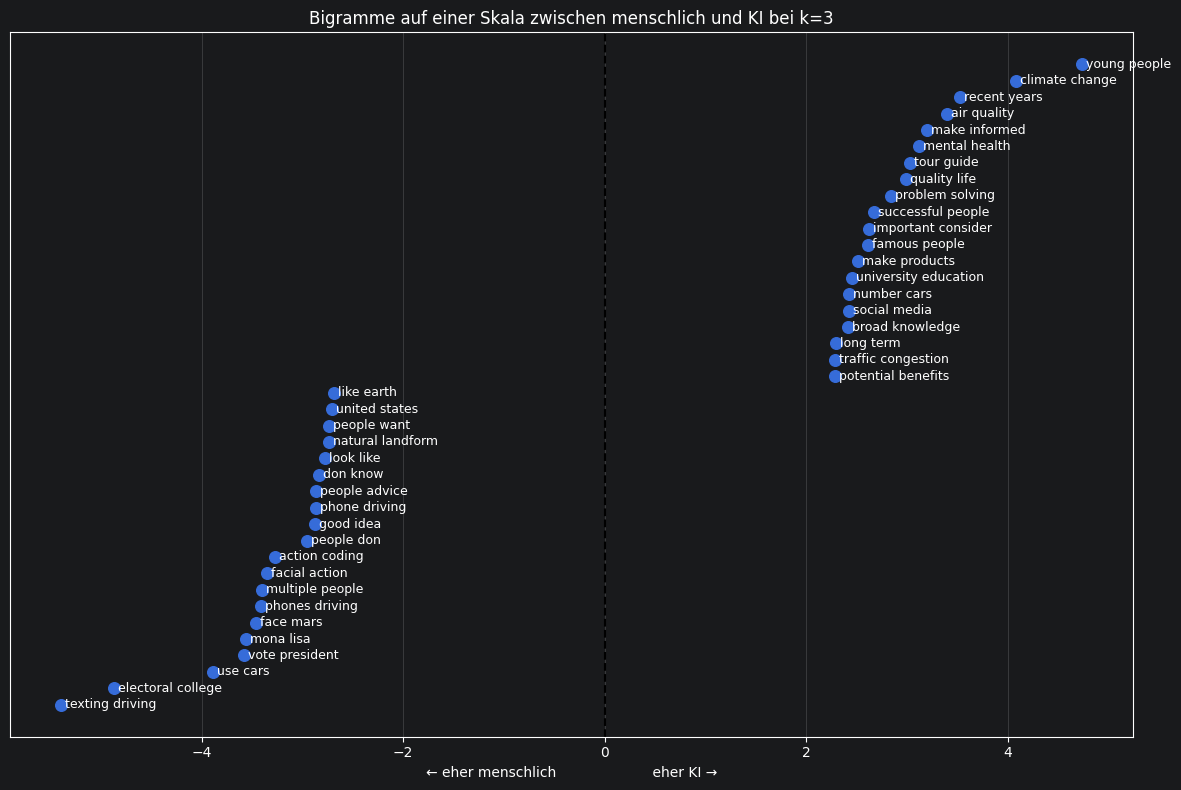

In [67]:
# Texte und Labels
X = df["text"]
Y = df["generated"]

# Erst Training (70 %) und Rest (30 %) erzeugen
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=42,
    stratify=Y
)

# Rest halbieren -> 15 % Validierung, 15 % Test
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=42,
    stratify=Y_temp
)

# TF-IDF-Vektorisierung
vectorizer = TfidfVectorizer(
    ngram_range=(2,2),
    stop_words="english"
)

X_train = vectorizer.fit_transform(X_train)
X_val = vectorizer.transform(X_val)
X_test = vectorizer.transform(X_test)


# k-NN trainieren (für die eigentliche Klassifikation)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, Y_train)

Y_val_pred = knn.predict(X_val)

print("Validierungsgenauigkeit:",
      accuracy_score(Y_val, Y_val_pred))

Y_test_pred = knn.predict(X_test)

print("Testgenauigkeit:",
      accuracy_score(Y_test, Y_test_pred))

# ---------------------------------------------------------
# Nur für die Visualisierung:
# Logistische Regression liefert Gewichte für jedes Bigramm
# ---------------------------------------------------------

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, Y_train)

# Bigramme und ihre Gewichte
bigrams = vectorizer.get_feature_names_out()
weights = lr.coef_[0]

importance = pd.DataFrame({
    "Bigram": bigrams,
    "Gewicht": weights
})

importance = importance.sort_values("Gewicht")

# Die 20 menschlichsten und 20 KI-typischsten Bigramme
top = pd.concat([
    importance.head(20),
    importance.tail(20)
])

# Visualisierung
plt.figure(figsize=(12, 8))

plt.scatter(
    top["Gewicht"],
    range(len(top)),
    s=70
)

for i, (_, row) in enumerate(top.iterrows()):
    plt.text(
        row["Gewicht"],
        i,
        " " + row["Bigram"],
        va="center",
        fontsize=9
    )

plt.axvline(0, color="black", linestyle="--")

plt.xlabel("← eher menschlich                      eher KI →")
plt.yticks([])

plt.title("Bigramme auf einer Skala zwischen menschlich und KI bei k=3")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Validierungsgenauigkeit: 0.9471637694419031
Testgenauigkeit: 0.9471637694419031


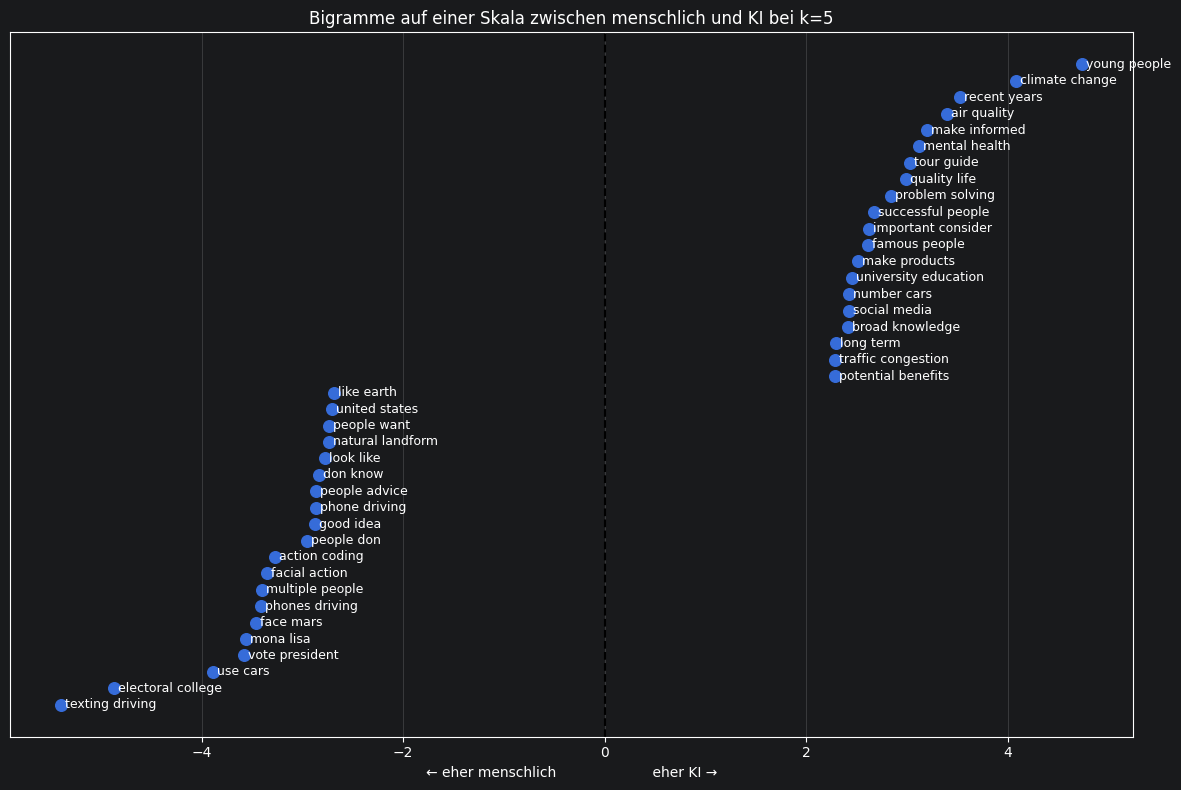

In [68]:
# Texte und Labels
X = df["text"]
Y = df["generated"]

# Erst Training (70 %) und Rest (30 %) erzeugen
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=42,
    stratify=Y
)

# Rest halbieren -> 15 % Validierung, 15 % Test
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=42,
    stratify=Y_temp
)

# TF-IDF-Vektorisierung
vectorizer = TfidfVectorizer(
    ngram_range=(2,2),
    stop_words="english"
)

X_train = vectorizer.fit_transform(X_train)
X_val = vectorizer.transform(X_val)
X_test = vectorizer.transform(X_test)

# k-NN trainieren (für die eigentliche Klassifikation)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, Y_train)

Y_val_pred = knn.predict(X_val)

print("Validierungsgenauigkeit:",
      accuracy_score(Y_val, Y_val_pred))

Y_test_pred = knn.predict(X_test)

print("Testgenauigkeit:",
      accuracy_score(Y_test, Y_test_pred))

# ---------------------------------------------------------
# Nur für die Visualisierung:
# Logistische Regression liefert Gewichte für jedes Bigramm
# ---------------------------------------------------------

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, Y_train)

# Bigramme und ihre Gewichte
bigrams = vectorizer.get_feature_names_out()
weights = lr.coef_[0]

importance = pd.DataFrame({
    "Bigram": bigrams,
    "Gewicht": weights
})

importance = importance.sort_values("Gewicht")

# Die 20 menschlichsten und 20 KI-typischsten Bigramme
top = pd.concat([
    importance.head(20),
    importance.tail(20)
])

# Visualisierung
plt.figure(figsize=(12, 8))

plt.scatter(
    top["Gewicht"],
    range(len(top)),
    s=70
)

for i, (_, row) in enumerate(top.iterrows()):
    plt.text(
        row["Gewicht"],
        i,
        " " + row["Bigram"],
        va="center",
        fontsize=9
    )

plt.axvline(0, color="black", linestyle="--")

plt.xlabel("← eher menschlich                      eher KI →")
plt.yticks([])

plt.title("Bigramme auf einer Skala zwischen menschlich und KI bei k=5")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [70]:
# Texte und Labels
X = df["text"]
Y = df["generated"]

# Erst Training (70 %) und Rest (30 %) erzeugen
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=42,
    stratify=Y
)

# Rest halbieren -> 15 % Validierung, 15 % Test
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=42,
    stratify=Y_temp
)

# TF-IDF-Vektorisierung
vectorizer = TfidfVectorizer(
    ngram_range=(2,2),
    stop_words="english"
)

X_train = vectorizer.fit_transform(X_train)
X_val = vectorizer.transform(X_val)
X_test = vectorizer.transform(X_test)

# k-NN trainieren (für die eigentliche Klassifikation)
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, Y_train)

print('k=10')

Y_val_pred = knn.predict(X_val)

print("Validierungsgenauigkeit:",
      accuracy_score(Y_val, Y_val_pred))

Y_test_pred = knn.predict(X_test)

print("Testgenauigkeit:",
      accuracy_score(Y_test, Y_test_pred))


# k-NN trainieren (für die eigentliche Klassifikation)
knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X_train, Y_train)

print('k=20')

Y_val_pred = knn.predict(X_val)

print("Validierungsgenauigkeit:",
      accuracy_score(Y_val, Y_val_pred))

Y_test_pred = knn.predict(X_test)

print("Testgenauigkeit:",
      accuracy_score(Y_test, Y_test_pred))


# k-NN trainieren (für die eigentliche Klassifikation)
knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(X_train, Y_train)

print('k=50')

Y_val_pred = knn.predict(X_val)

print("Validierungsgenauigkeit:",
      accuracy_score(Y_val, Y_val_pred))

Y_test_pred = knn.predict(X_test)

print("Testgenauigkeit:",
      accuracy_score(Y_test, Y_test_pred))

k=10
Validierungsgenauigkeit: 0.9551692589204026
Testgenauigkeit: 0.9499085086916743
k=20
Validierungsgenauigkeit: 0.9494510521500458
Testgenauigkeit: 0.9535681610247027
k=50
Validierungsgenauigkeit: 0.9471637694419031
Testgenauigkeit: 0.9414455626715462


# Methodenlager

In [ ]:
def calculate_f1_score(true_positive, false_positive, true_negative, false_negative):

    denominator = (2 * true_positive) + false_positive + false_negative

    if denominator == 0:
        return 0.0

    return (2 * true_positive) / denominator



# Testdataframedefinition

In [ ]:
# Texte und Labels
X = df["text"]
Y = df["generated"]

# Erst Training (80 %) und Rest (20 %) erzeugen
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)

# Rest halbieren -> 15 % Validierung, 15 % Test
X_val, X_test, Y_val, Y_test = train_test_split(
    X_train,
    Y_train,
    test_size=0.50,
    random_state=42,
    stratify=Y_temp
)

# TF-IDF-Vektorisierung
vectorizer = TfidfVectorizer(
    ngram_range=(2,2),
    stop_words="english"
)

X_train = vectorizer.fit_transform(X_train)
X_val = vectorizer.transform(X_val)
X_test = vectorizer.transform(X_test)

# k-NN trainieren (für die eigentliche Klassifikation)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, Y_train)

Y_val_pred = knn.predict(X_val)

print("Validierungsgenauigkeit:",
      accuracy_score(Y_val, Y_val_pred))

Y_test_pred = knn.predict(X_test)

print("Testgenauigkeit:",
      accuracy_score(Y_test, Y_test_pred))

In [ ]:
# -----------------------------
# Daten aufteilen
# -----------------------------
X = df["text"]
Y = df["generated"]

# Nur Train/Test-Split, Daten werden zufällig aufgeteilt
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20, # 20% der Daten werden komplett zurück gelegt, sie werden bis zum Schluss nie verwendet
    random_state=42, # hierdurch erhält man jedes Mal dieselbe Aufteilung = Reproduzierbarkeit
    stratify=Y # erhält die Klassenverteilung (prozentuale Verteilung von KI-generiert und menschlich bleibt erhalten)
)

# -----------------------------
# TF-IDF, Texte werden in Zahlen umgewandelt und somit maschinenlesbar
# -----------------------------
vectorizer = TfidfVectorizer(
    ngram_range=(2,2), # es werden nur Bigramme verwendet
    stop_words="english" # englische Füllwörter werden entfernt
)

X_train_vec = vectorizer.fit_transform(X_train) # vectorizer lernt den Wortschatz und wandelt danach jeden Text in einen Zahlenwert um (Vectorizer schaut sich an welche Wörter existieren, wie häufig sie vorkommen und wie der IDF-Wert aussieht)
X_test_vec = vectorizer.transform(X_test) # hier wird keiner neuer Wortschatz gelernt, sondern ausschließlich der bereits gelernte verwendet

# -----------------------------
# k-Fold vorbereiten, Trainingsdaten werden in fünf Teile zerlegt
# -----------------------------
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# jetzt sollen verschiedene k-NN-Modelle verglichen werden
k_values = [1, 3, 5, 7, 9, 11]

# hier werden jetzt die Fehlerlisten "geboren" (noch sind sie leer)
train_error = []
cv_error = []
test_error = []

# -----------------------------
# Modelle vergleichen
# -----------------------------
# hier haben wir eine Schleife über jedes Modell
for k in k_values:
    # hier sammeln wir die accuracy
    train_scores = []
    val_scores = []

    # 5-fache Cross Validation
    for train_idx, val_idx in cv.split(X_train_vec, Y_train):
        # es werden nur Traininsdaten dieses folds genommen
        X_fold_train = X_train_vec[train_idx]
        X_fold_val = X_train_vec[val_idx]

        Y_fold_train = Y_train.iloc[train_idx]
        Y_fold_val = Y_train.iloc[val_idx]

        # jetzt wird das Modell trainiert
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_fold_train, Y_fold_train)

        # Vorhersage auf den Trainingsdaten
        train_pred = knn.predict(X_fold_train)
        # Vorhersage auf den Validierungssdaten
        val_pred = knn.predict(X_fold_val)

        # jetzt die accuracy berechnen und ablegen
        train_scores.append(accuracy_score(Y_fold_train, train_pred))
        val_scores.append(accuracy_score(Y_fold_val, val_pred))

    # Mittelwerte über alle Folds
    mean_train = np.mean(train_scores)
    mean_val = np.mean(val_scores)

    train_error.append(1 - mean_train)
    cv_error.append(1 - mean_val)

    # -----------------------------
    # Testbewertung
    # -----------------------------
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_vec, Y_train)

    test_pred = knn.predict(X_test_vec)
    test_acc = accuracy_score(Y_test, test_pred)

    test_error.append(1 - test_acc)

    print(f"k = {k}")
    print(f"Train Accuracy (CV): {mean_train:.4f}")
    print(f"Validierungs Accuracy (CV): {mean_val:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}\n")

# -----------------------------
# Visualisierung
# -----------------------------
plt.figure(figsize=(9,5))

plt.plot(k_values, train_error, marker="o", label="Trainingsfehler")
plt.plot(k_values, cv_error, marker="s", label="Validierungsfehler (5-Fold)")
plt.plot(k_values, test_error, marker="^", label="Testfehler")

plt.xlabel("k")
plt.ylabel("Fehler (1 - Accuracy)")
plt.title("k-NN mit 5-facher Cross Validation")
plt.xticks(k_values)
plt.grid(True)
plt.legend()

plt.show()